# 📈 💸 Time Series - Apple Stock Price with the Box Jenkins methods - DavyDW - Solution version

Last update: Monday, August 4th, 2025

## ℹ️ Readme

* ✍️ This challenge was written by [davydw](https://github.com/davydw)
* 🎯 The goal is to predict Apple Stock Price in the future using <font color="red">AR</font><font color="green">I</font><font color="blue">MA</font> model
* 🚓 It is designed only for students of `Le Wagon - Batch 2079 - Amsterdam` and cannot be reproduced without davydw's authorization. Indeed, he is no longer working as a full time employee at Le Wagon. Hence, the latter cannot claim and publish this recap on their learning platform `Kitt` without his consent.


## 📚 Libraries

In [47]:
# DATA MANIPULATION
import pandas as pd
import numpy as np
import datetime

# DATA VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns

# STATSMODELS = TIME SERIES ANALYSIS
## DECOMPOSITION
from statsmodels.tsa.seasonal import seasonal_decompose
## STATIONARITY ANALYSIS - HOW MANY ORDERS OF DIFFERENCING
from statsmodels.tsa.stattools import adfuller
from pmdarima.arima.utils import ndiffs
## ACF AND PACF
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
## ARIMA / SARIMA
from statsmodels.tsa.arima.model import ARIMA
## STATS GRIDSEARCH
import pmdarima as pm
## PLOT PREDICTION
from statsmodels.graphics.tsaplots import plot_predict

▶️ Run the following cell to install `yfinance`

In [48]:
# !pip install yfinance

## 👨🏻‍🏫 Box Jenkins Method

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/time_serie_process_overview.jpg">

## (0) 👓 VISUALIZE

### (0.1) 💾 AAPL (1985-2023)

📈 [Apple Stock Price since 1985](https://finance.yahoo.com/quote/AAPL/history?period1=345427200&period2=1677715200&interval=1mo&filter=history&frequency=1mo&includeAdjustedClose=true) - *Source: Yahoo Finance*

▶️ Run these cells to download the historical data for Apple Stock Price

In [49]:
!ls

AAPL_monthly_yahoo_1985_2023.csv
TimeSeries_BoxJenkinsMethod_Apple_Stock_Price-Solution-2025-08-04.ipynb
TimeSeries_BoxJenkinsMethod_Apple_Stock_Price-Students-2025-08-04.ipynb


In [50]:
# import yfinance as yf
# df = yf.download("AAPL")

df = pd.read_csv("AAPL_monthly_yahoo_1985_2023.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,1985-01-01,0.130022,0.138951,0.124442,0.129464,0.100589,6366416000
1,1985-02-01,0.129464,0.137277,0.110491,0.110491,0.085847,4733388800
2,1985-03-01,0.110491,0.116071,0.092634,0.098772,0.076742,4615587200
3,1985-04-01,0.098772,0.102679,0.087612,0.094866,0.073707,2868028800
4,1985-05-01,0.094866,0.099330,0.075335,0.077567,0.060267,4639129600
...,...,...,...,...,...,...,...
454,2022-11-01,155.080002,155.449997,134.380005,148.029999,147.559555,1724847700
455,2022-12-01,148.210007,150.919998,125.870003,129.929993,129.731918,1675657600
456,2023-01-01,130.279999,147.229996,124.169998,144.289993,144.070023,1443218300
457,2023-02-01,143.970001,157.380005,141.320007,147.410004,147.185272,1307127200


In [51]:
# yf.download(["AAPL", "MSFT", "GOOG"])

In [52]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
454,2022-11-01,155.080002,155.449997,134.380005,148.029999,147.559555,1724847700
455,2022-12-01,148.210007,150.919998,125.870003,129.929993,129.731918,1675657600
456,2023-01-01,130.279999,147.229996,124.169998,144.289993,144.070023,1443218300
457,2023-02-01,143.970001,157.380005,141.320007,147.410004,147.185272,1307127200
458,2023-03-01,146.830002,147.229996,145.009995,145.309998,145.309998,55387700


⏰ Convert the date column into a `datetime` column.

In [53]:
df.index

RangeIndex(start=0, stop=459, step=1)

👉 Keep only the `Close` column.

In [54]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1985-01-01,0.130022,0.138951,0.124442,0.129464,0.100589,6366416000
1,1985-02-01,0.129464,0.137277,0.110491,0.110491,0.085847,4733388800
2,1985-03-01,0.110491,0.116071,0.092634,0.098772,0.076742,4615587200
3,1985-04-01,0.098772,0.102679,0.087612,0.094866,0.073707,2868028800
4,1985-05-01,0.094866,0.099330,0.075335,0.077567,0.060267,4639129600


In [55]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [56]:
df = df[['Date','Close']]
df

,Date,Close
0,1985-01-01,0.129464
1,1985-02-01,0.110491
2,1985-03-01,0.098772
3,1985-04-01,0.094866
4,1985-05-01,0.077567
...,...,...
454,2022-11-01,148.029999
455,2022-12-01,129.929993
456,2023-01-01,144.289993
457,2023-02-01,147.410004


### (0.2) 💹 First glimpse

📈 Visualize your Time Series

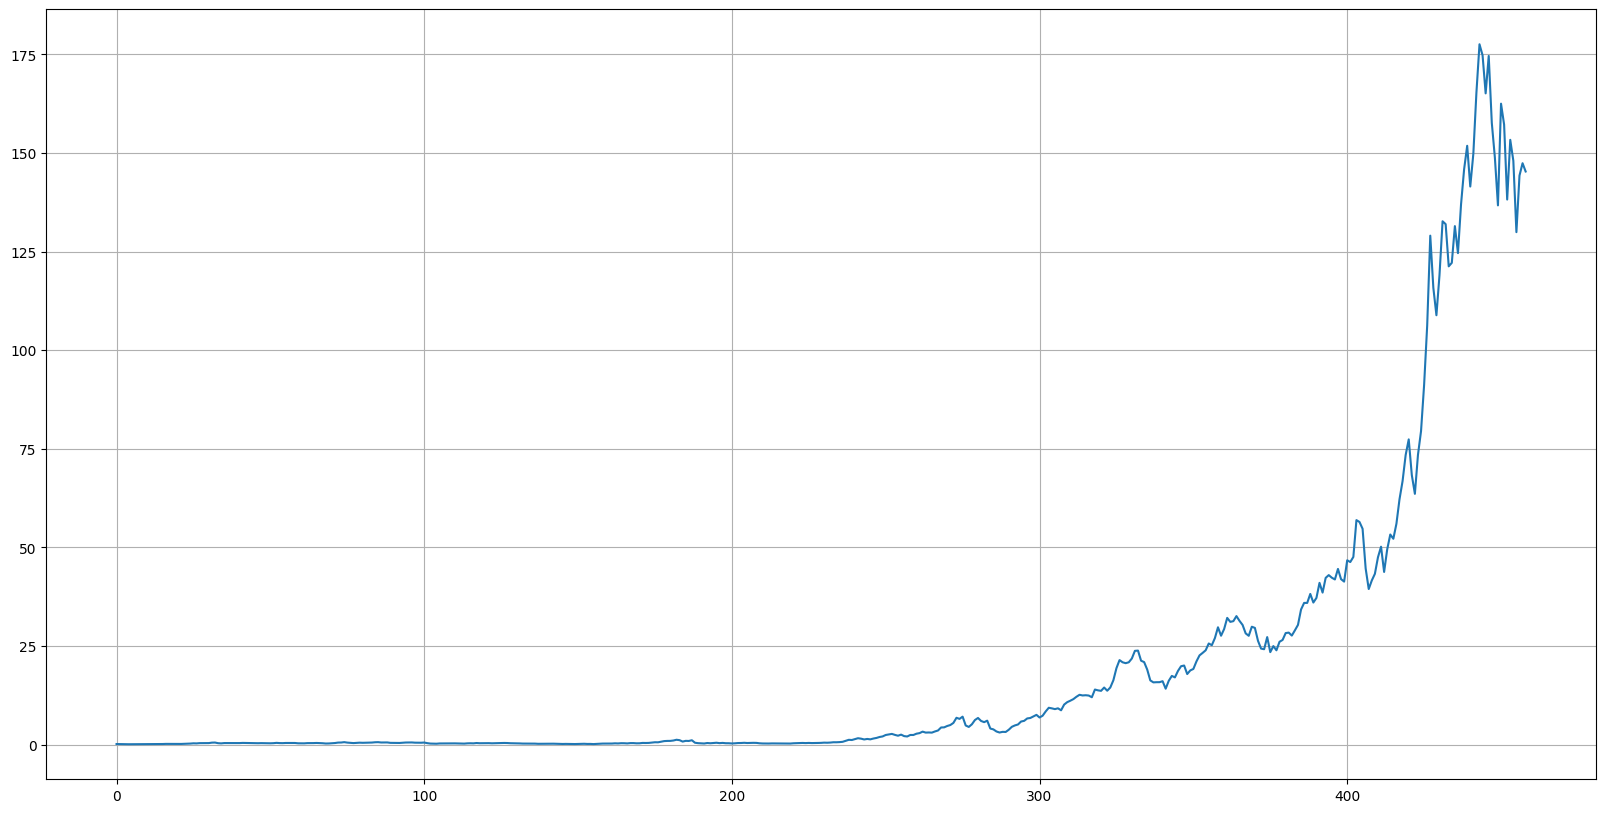

In [57]:
plt.figure(figsize=(20,10))
df["Close"].plot()
plt.grid()
plt.show();

### (0.3) 📏 Linearizing

📈 Exponential growth... consider the logarithm of the TS instead and visualize the "logarithmized" TS

In [58]:
df["LogClose"] = np.log(df["Close"])
df.tail(5)

/var/folders/6p/s5dyg_x13_zbgfd_xsyg3s7c0000gn/T/ipykernel_11155/2456092760.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["LogClose"] = np.log(df["Close"])


,Date,Close,LogClose
454,2022-11-01,148.029999,4.997415
455,2022-12-01,129.929993,4.866996
456,2023-01-01,144.289993,4.971825
457,2023-02-01,147.410004,4.993218
458,2023-03-01,145.309998,4.978869


👆 **Warnings**

* Time Series with negative values can't be decomposed multiplicatively...
* Apple stock price started skyrocketing after 2009...
* If you read a bit about Financial News, Apple proceeded to a stock split:
    - [Investopedia - Stocksplit](https://www.investopedia.com/terms/s/stocksplit.asp)
    - [Forbes 2020/07/31 - Apple announces a 4-for-1 split](https://www.forbes.com/sites/lcarrel/2020/07/31/apple-announces-4-for-1-stock-split-to-bring-in-new-investors/?sh=626f2e755401)

📆 Filter out the TS to keep values only starting from January 1st, 2020 and visualize it.

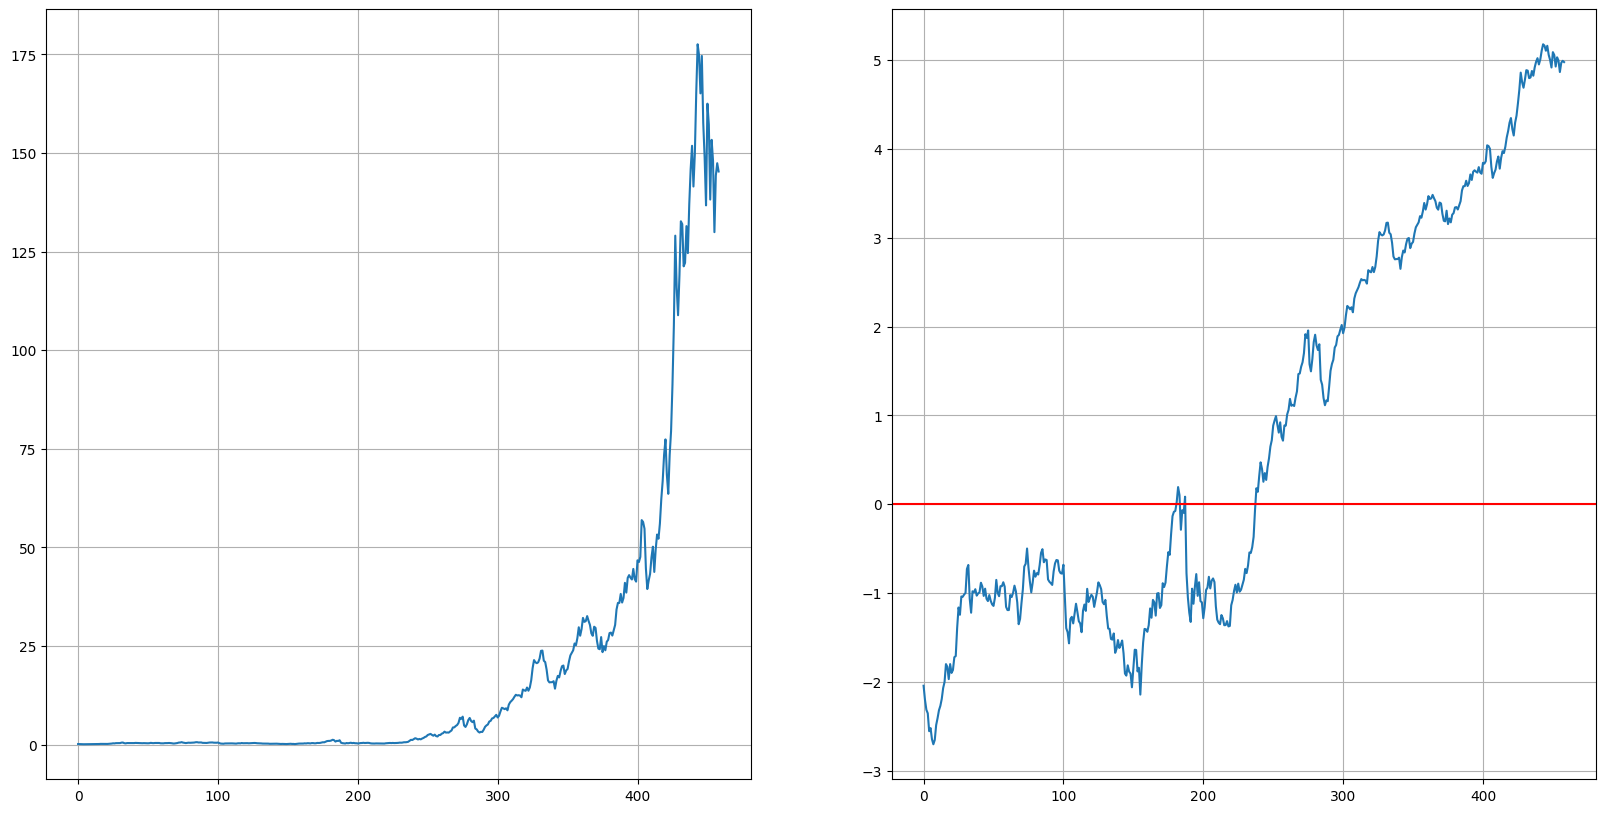

In [59]:
fig, ax = plt.subplots(1,2, figsize=(20,10))

ax[0].plot(df["Close"], label="close")
ax[0].grid()

ax[1].plot(df["LogClose"], label="LogClose")
ax[1].axhline(y=0, color = 'red', linestyle = '-')
ax[1].grid()

plt.show();

In [60]:
date_after = datetime.date(2020, 1, 1)
date_after

datetime.date(2020, 1, 1)

In [61]:
df.dtypes

Date         object
Close       float64
LogClose    float64
dtype: object

In [62]:
df["Date"] = pd.to_datetime(df["Date"])
df

/var/folders/6p/s5dyg_x13_zbgfd_xsyg3s7c0000gn/T/ipykernel_11155/3762405922.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Date"] = pd.to_datetime(df["Date"])


,Date,Close,LogClose
0,1985-01-01,0.129464,-2.044352
1,1985-02-01,0.110491,-2.202821
2,1985-03-01,0.098772,-2.314941
3,1985-04-01,0.094866,-2.355290
4,1985-05-01,0.077567,-2.556613
...,...,...,...
454,2022-11-01,148.029999,4.997415
455,2022-12-01,129.929993,4.866996
456,2023-01-01,144.289993,4.971825
457,2023-02-01,147.410004,4.993218


In [63]:
df["Date"].dt.date > date_after

0      False
1      False
2      False
3      False
4      False
       ...  
454     True
455     True
456     True
457     True
458     True
Name: Date, Length: 459, dtype: bool

In [64]:
df = df[df["Date"].dt.date > date_after]
df.set_index("Date", inplace = True)
df.sort_index(inplace=True)

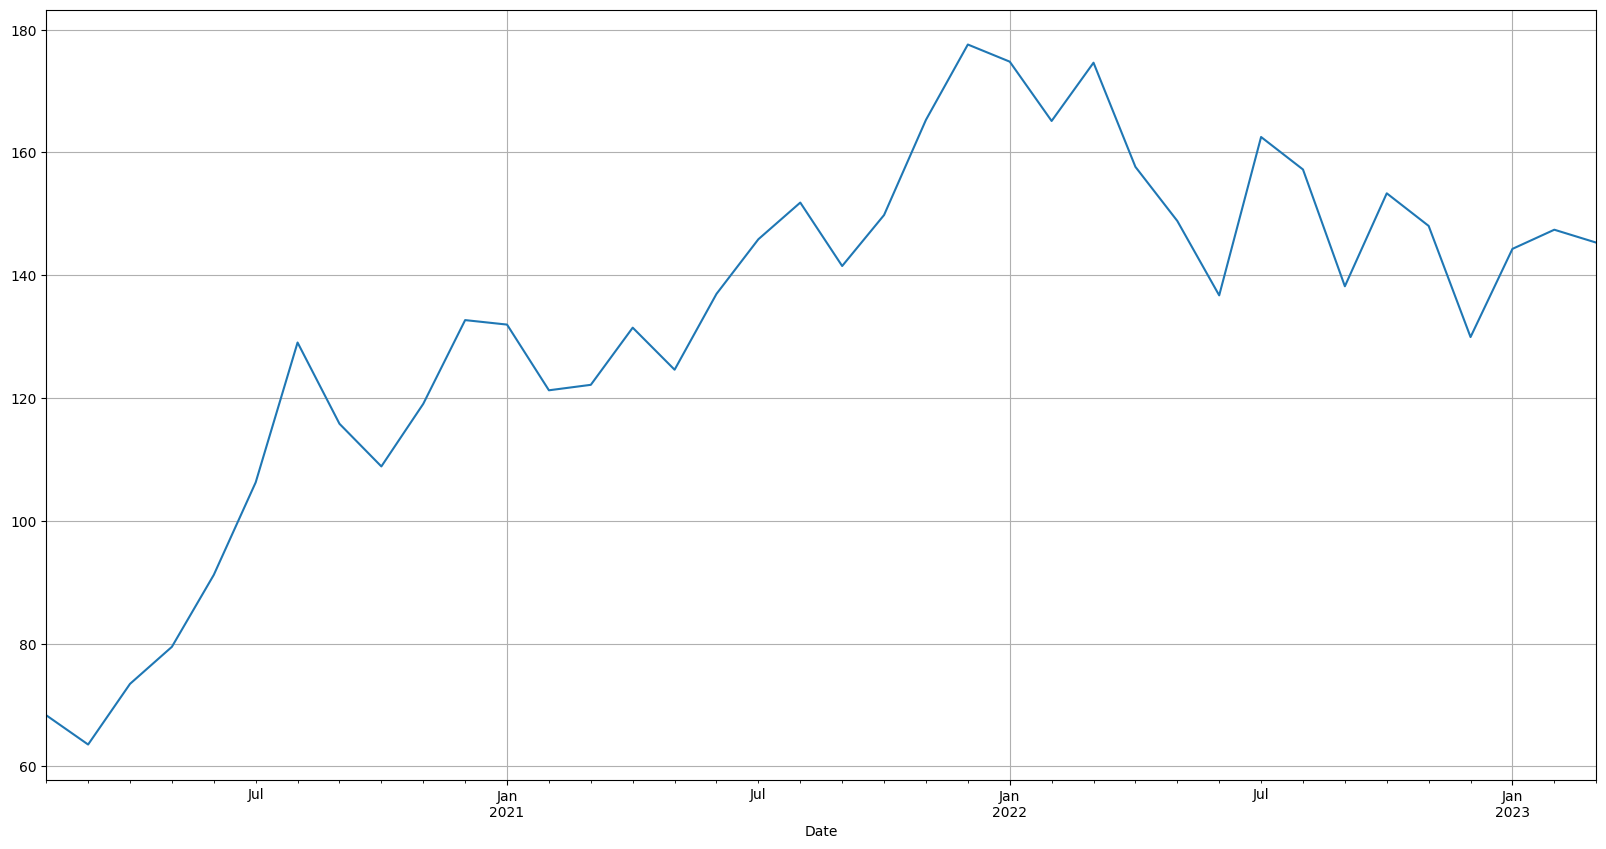

In [65]:
plt.figure(figsize=(20,10))
df["Close"].plot()
plt.grid()
plt.show;

## (1) 👩🏾‍🔬 DECOMPOSE

### (1.1) 🐣 Decomposition of the "original" Time Series

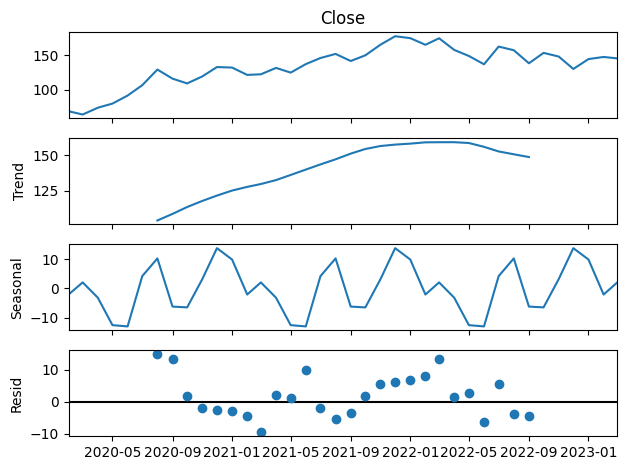

In [66]:
# Additive Decomposition (y = Trend + Seasonal + Residuals)
result_add = seasonal_decompose(df["Close"] , model='additive')
result_add.plot();

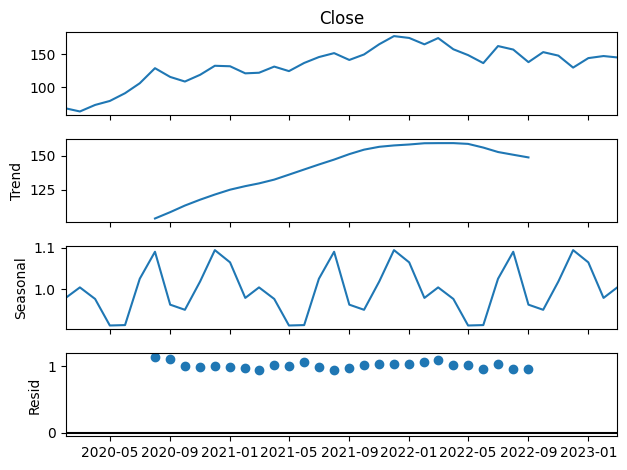

In [67]:
# Multiplicative Decomposition (y = Trend * Seasonal * Residuals)
result_mult = seasonal_decompose(df["Close"] , model='multiplicative')
result_mult.plot();

In [68]:
# Comparing the ADF tests for both residuals
print(f"ADF for the additive residuals = {adfuller(result_add.resid.dropna())[1]}")
print(f"ADF for the multiplicative residuals = {adfuller(result_mult.resid.dropna())[1]}")


ADF for the additive residuals = 0.19869956585540666
ADF for the multiplicative residuals = 0.004058862113434733


### (1.2) 🐓 Decomposition the "logarithmized" Time Series

In [69]:
df

,Close,LogClose
Date,,
2020-02-01,68.339996,4.224495
2020-03-01,63.572498,4.152181
2020-04-01,73.449997,4.296605
2020-05-01,79.485001,4.375568
2020-06-01,91.199997,4.513055
2020-07-01,106.260002,4.665889
2020-08-01,129.039993,4.860122
2020-09-01,115.809998,4.751951
2020-10-01,108.860001,4.690063


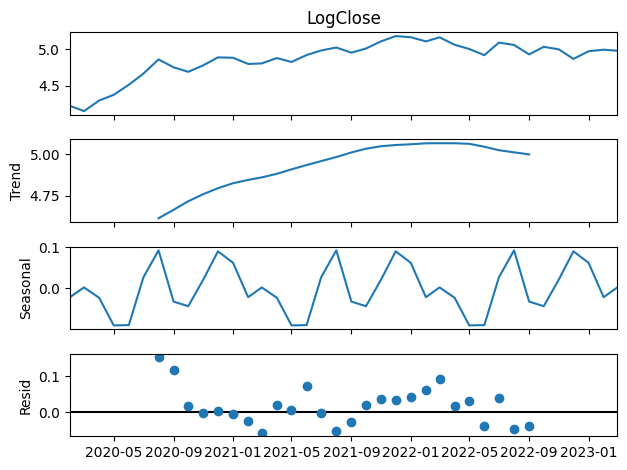

In [71]:
# Additive Decomposition (np.log(y) = Trend + Seasonal + Residuals)
result_add_log = seasonal_decompose(df["LogClose"] , model='additive')
result_add_log.plot();

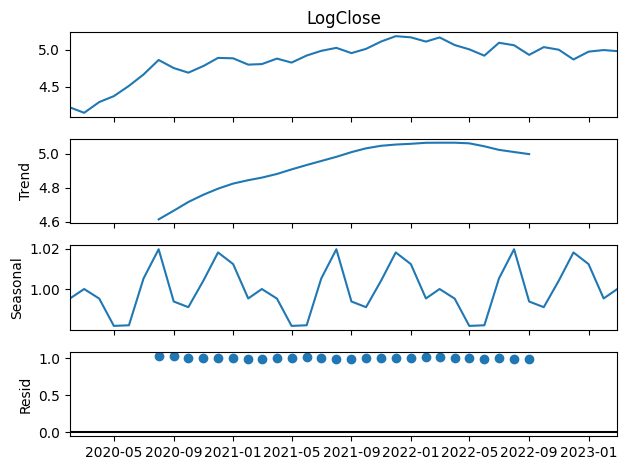

In [72]:
# Multiplicative Decomposition (np.log(y) = Trend * Seasonal * Residuals)
result_mult_log = seasonal_decompose(df["LogClose"] , model='multiplicative')
result_mult_log.plot();

In [73]:
# Comparing the ADF tests for both residuals
print(f"ADF for the additive residuals = {adfuller(result_add_log.resid.dropna())[1]}")
print(f"ADF for the multiplicative residuals = {adfuller(result_mult_log.resid.dropna())[1]}")

ADF for the additive residuals = 0.004492489649264436
ADF for the multiplicative residuals = 0.003420737882383294


### (1.3) 🔄 Remove seasonality

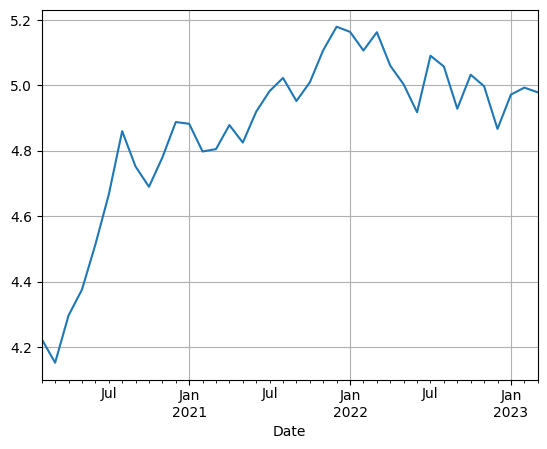

In [74]:
# Reminder: before removing seasonality
df["LogClose"].plot()
plt.grid()

In [75]:
# Removing the multiplicative seasonal component
df["DeseasonalizedLogClose"] = df["LogClose"]/result_mult_log.seasonal

/var/folders/6p/s5dyg_x13_zbgfd_xsyg3s7c0000gn/T/ipykernel_11155/4214271850.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["DeseasonalizedLogClose"] = df["LogClose"]/result_mult_log.seasonal


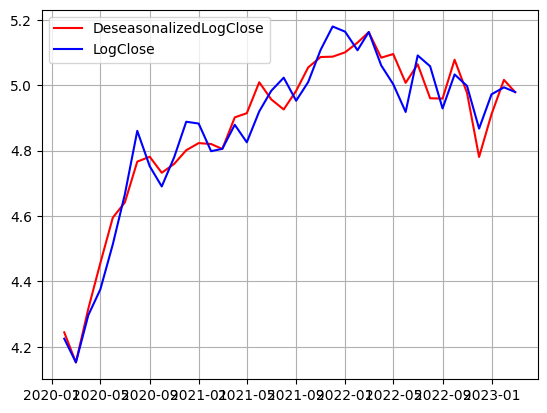

In [76]:
# Having a look at the deseasonalized LogClose
plt.plot(df["DeseasonalizedLogClose"], label="DeseasonalizedLogClose", c='red')
plt.plot(df["LogClose"], label="LogClose", c='blue')
plt.grid()
plt.legend(loc="best")
plt.show()

👆 Our intuition is confirmed, there is no seasonality in the historic values of the `AAPL` stock price. But we can still work with the deseasonalized version and re-introduce it during the forecasts.

## (2) 🗿 STATIONARITY / DIFFERENCING

🕵️‍♂️ How many times should you differentiate the logarithmized TS to achieve stationarity?

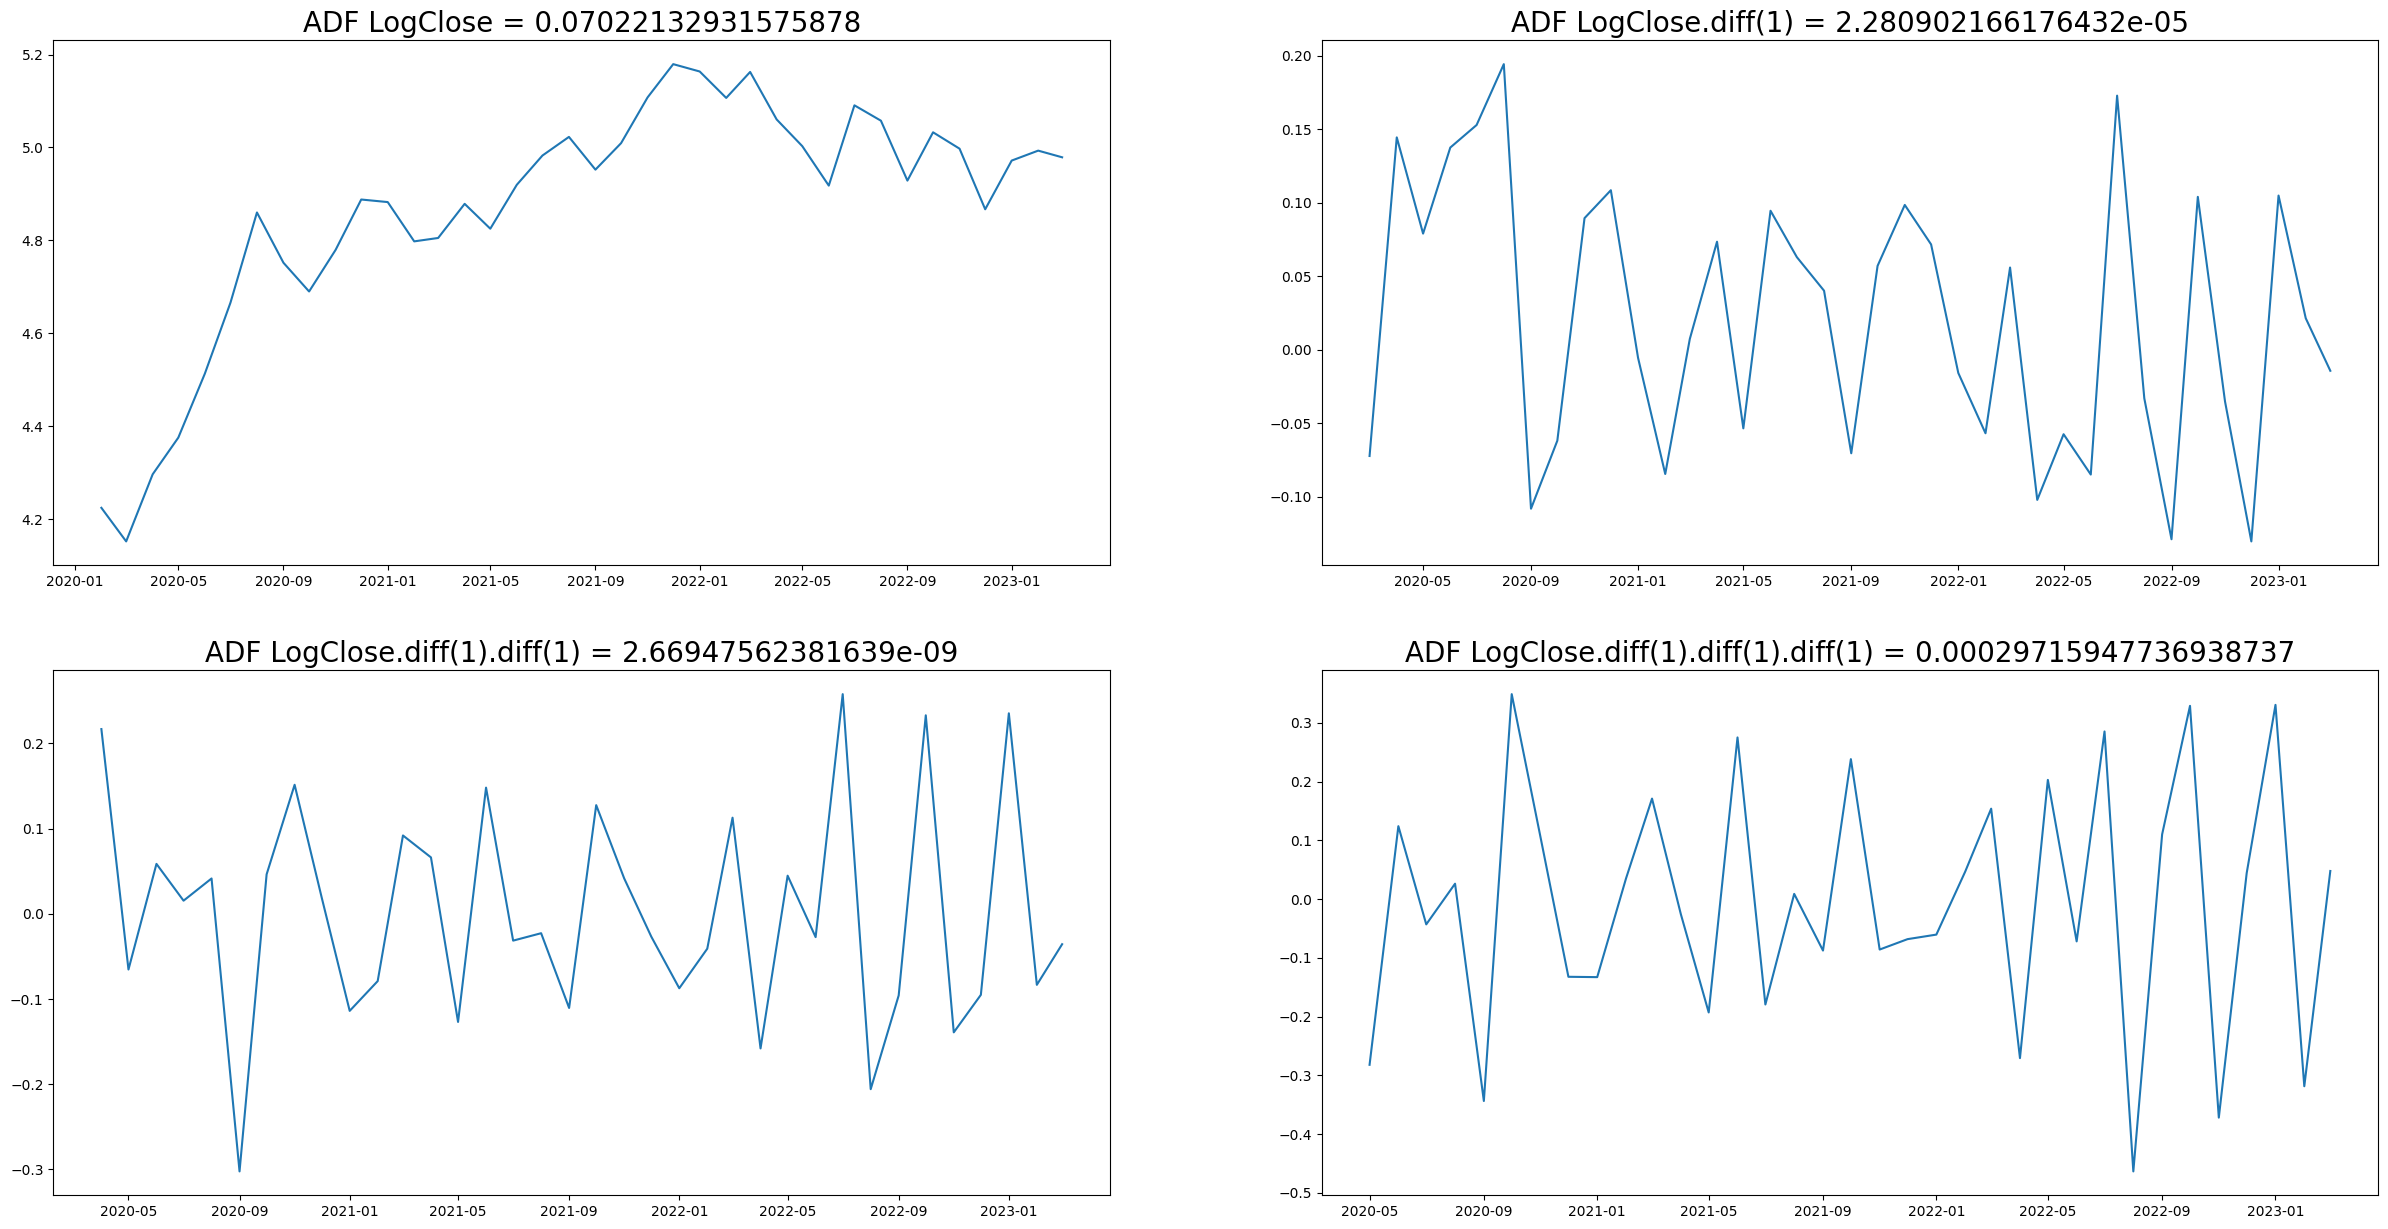

In [77]:
fig, ax = plt.subplots(2,2, figsize = (30,15))

ax[0][0].set_title(f"ADF LogClose = {adfuller(df.LogClose)[1]}", size = 20)
ax[0][0].plot(df["LogClose"])

ax[0][1].set_title(f"ADF LogClose.diff(1) = {adfuller(df.LogClose.diff(1).dropna())[1]}", size = 20)
ax[0][1].plot(df["LogClose"].diff(1).dropna())

ax[1][0].set_title(f"ADF LogClose.diff(1).diff(1) = {adfuller(df.LogClose.diff(1).diff(1).dropna())[1]}", size = 20)
ax[1][0].plot(df["LogClose"].diff(1).diff(1).dropna())

ax[1][1].set_title(f"ADF LogClose.diff(1).diff(1).diff(1) = {adfuller(df.LogClose.diff(1).diff(1).diff(1).dropna())[1]}", size = 20)
ax[1][1].plot(df["LogClose"].diff(1).diff(1).diff(1).dropna())

plt.show();

👆 Diffencing $\color{green}{d=1}$ should be enough!

In [78]:
y_diff = df["LogClose"].diff(1).dropna()
y_diff_diff = df["LogClose"].diff(1).diff(1).dropna()
y_diff_diff_diff = df["LogClose"].diff(1).diff(1).diff(1).dropna()

## (3) ⚙ <font color="blue">ACF</font> and <font color="red">PACF</font>

* How many <font color="red">lags</font> should you use for the <font color="red">AR</font> part ?
* How many <font color="blue">lags</font> should you use for the <font color="blue">MA</font> part ?

In [79]:
len(df)

38

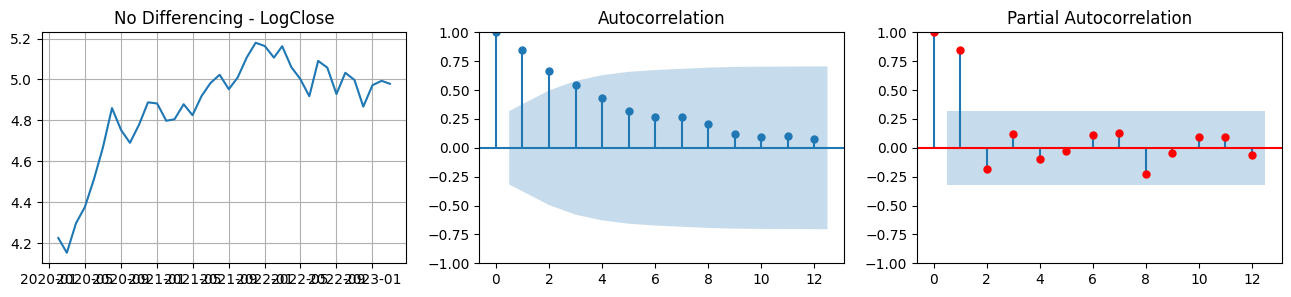

In [80]:
# LAGS MUST BE LOWER THAN 50% OF THE LEN(DF)
lags = 12

fig, ax = plt.subplots(1,3, figsize=(16,3))

ax[0].plot(df["LogClose"]);
ax[0].set_title("No Differencing - LogClose")
ax[0].grid()
plot_acf(df["LogClose"], lags=lags, ax=ax[1]);
plot_pacf(df["LogClose"], lags=lags, ax=ax[2], method='ywm' , color='r');

## (4) 🤖 <font color="red">AR</font><font color="green">I</font><font color="blue">MA</font> MODEL

### (4.1) 👀 Choosing parameters

In [226]:
p = 3 # PACF - RED
d = 1
q = 12 # ACF - BLUE

### (4.2) ✂️ Temporal <font color="blue">Train</font>-<font color="orange">Test</font> split

In [227]:
train_ratio = 0.70
train_index_last = int(train_ratio*len(df))
df_train = df.iloc[:train_index_last,:]
df_test = df.iloc[train_index_last:,:]

### (4.3) 🥋 <font color="blue">Training</font>

In [228]:
df_train.tail(3)

,Close,LogClose,DeseasonalizedLogClose
Date,,,
2022-01-01,174.779999,5.163528,5.100261
2022-02-01,165.119995,5.106672,5.130045
2022-03-01,174.610001,5.162555,5.162006


In [229]:
arima = ARIMA(df_train["DeseasonalizedLogClose"], order = (p,d,q))
arima = arima.fit();

/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  wa

## (5) 🔮 <font color="orange">FORECAST</font>

❗️ Keep in mind that we will have to revert to the "original" Time Series with two steps:
- "re-seasonalize"
- "exponentiate"

### (5.1) 🪄 Forecasting future values for the  "logarithmized" and "deseasonalized" TS

In [230]:
# Forecasting only the values without the confidence intervals
forecast_solo = arima.forecast(len(df_test), alpha=0.05)
forecast_solo

/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


2022-04-01    5.219335
2022-05-01    5.250095
2022-06-01    5.248146
2022-07-01    5.220507
2022-08-01    5.204095
2022-09-01    5.185643
2022-10-01    5.189156
2022-11-01    5.194030
2022-12-01    5.188253
2023-01-01    5.197996
2023-02-01    5.244967
2023-03-01    5.302637
Freq: MS, Name: predicted_mean, dtype: float64

In [231]:
# 95% confidence
forecast_results = arima.get_forecast(len(df_test), alpha=0.05)

# Forecasts
forecast = forecast_results.predicted_mean

# Confidence intervals
confidence_int = forecast_results.conf_int().values
lower_predicted_bounds = confidence_int[:,0]
upper_predicted_bounds = confidence_int[:,1]

### (5.2) 🦄 Recomposing the original Time Series and the predictions

**Wrap-up**

1. We started from `df["Close"]`
2. Applied the `logarithm` function
3. `Deseasonalized` `df["LogClose"]`

**Reconstruction steps**

Let's reverse-engineer the Time Series

1. Reseasonalize `df["LogClose"]` multiplying by `result_mult_log.seasonal`
2. Apply the `exponential function`

In [232]:
## TRAIN
train_reconstructed = np.exp(df_train["LogClose"]*result_mult_log.seasonal[:train_index_last])
len(train_reconstructed)

26

In [233]:
## TEST
test_reconstructed = np.exp(df_test["LogClose"]*result_mult_log.seasonal[train_index_last:])
len(test_reconstructed)

12

In [234]:
## FORECASTS
forecast_reconstructed = np.exp(forecast*result_mult_log.seasonal[train_index_last:])
len(forecast_reconstructed)

12

In [235]:
forecast.shape

(12,)

In [236]:
## LOWER BOUND
lower_reconstructed = np.exp(lower_predicted_bounds*result_mult_log.seasonal[train_index_last:])
len(lower_reconstructed)

12

In [237]:
## UPPER BOUND
upper_reconstructed = np.exp(upper_predicted_bounds*result_mult_log.seasonal[train_index_last:])
len(upper_reconstructed)

12

### (5.3) 📈 Plots

In [238]:
def plot_forecast(fc, train, test,lower=None,upper=None):
    is_confidence_int = isinstance(upper, np.ndarray) and isinstance(lower, np.ndarray)
    # Prepare plot series
    fc_series = pd.Series(fc, index=test.index)
    lower_series = pd.Series(upper, index=test.index) if is_confidence_int else None
    upper_series = pd.Series(lower, index=test.index) if is_confidence_int else None

    # Plot
    plt.figure(figsize=(10,4), dpi=100)
    plt.plot(train, label='training', color='black')
    plt.plot(test, label='actual', color='black', ls='--')
    plt.plot(fc_series, label='forecast', color='orange')
    if is_confidence_int:
        plt.fill_between(lower_series.index, lower_series, upper_series, color='k', alpha=.15)
    plt.title('Forecast vs Actuals')
    plt.grid()
    plt.legend(loc='upper left', fontsize=8);


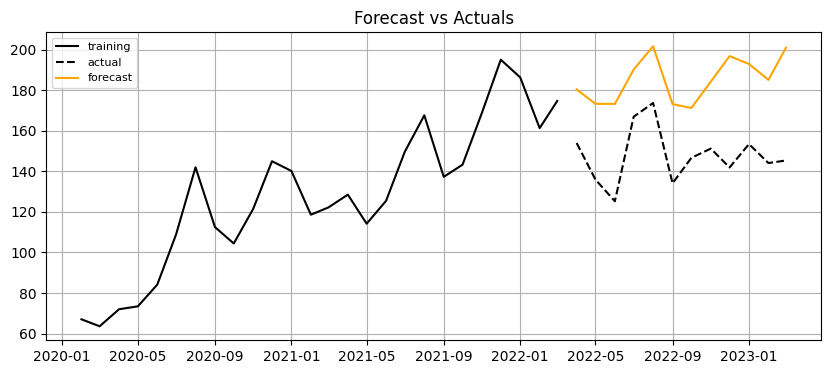

In [239]:
plot_forecast(forecast_reconstructed,
              train_reconstructed,
              test_reconstructed,
              lower_reconstructed,
              upper_reconstructed
             )

